<a href="https://colab.research.google.com/github/SHAIKYASIN2003/-Administration-Portal/blob/main/Final_Internship_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import pandas as pd
import zipfile
import os

# Define the path to the ZIP file provided by the user
zip_file_path = '/content/archive (6).zip'
extract_dir = '/content/extracted_data' # Directory to extract files into

# Ensure the extraction directory exists
os.makedirs(extract_dir, exist_ok=True)

try:
    # Unzip the file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f'Successfully extracted: {zip_file_path} to {extract_dir}')

    # List files in the extracted directory to find the CSV
    csv_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

    if not csv_files:
        raise ValueError(f"No CSV file found in the extracted archive at {extract_dir}.")

    # Assuming the first CSV file found is the correct one
    # If there are multiple CSVs, you might need to specify which one to load.
    file_to_load = os.path.join(extract_dir, csv_files[0])

    # Load the dataset into a pandas DataFrame
    df = pd.read_csv(file_to_load)
    print(f'Successfully loaded dataset from: {file_to_load}')

    # Display the first 5 rows of the dataset
    print('\nFirst 5 rows of the dataset:')
    display(df.head())

    # Display information about the DataFrame
    print('\nDataFrame Info:')
    df.info()
except FileNotFoundError:
    print(f'Error: The ZIP file {zip_file_path} was not found. Please check the path and ensure the file exists.')
except zipfile.BadZipFile:
    print(f'Error: {zip_file_path} is not a valid ZIP file or is corrupted.')
except Exception as e:
    print(f'An error occurred while loading or processing the dataset: {e}')


Successfully extracted: /content/archive (6).zip to /content/extracted_data
Successfully loaded dataset from: /content/extracted_data/Loan_default.csv

First 5 rows of the dataset:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object

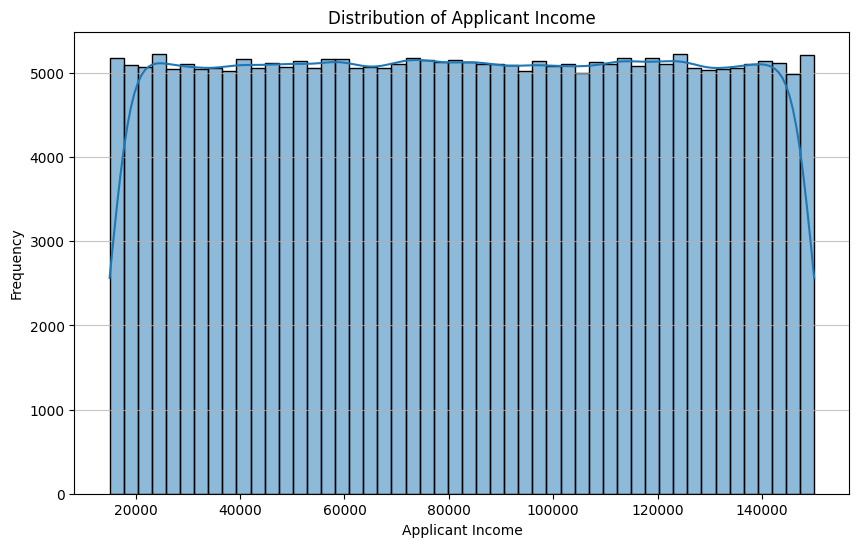

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of 'Income'
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], bins=50, kde=True)
plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Correlation Matrix for Numerical Features

In [8]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_features].corr()
display(correlation_matrix)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


### Training a Classification Model

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
X = df[['Income', 'LoanAmount']]
y = df['Default']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 204277 samples
Testing set size: 51070 samples


#### Train the Logistic Regression Model

In [11]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


#### Evaluate the Model

In [12]:
# Initialize and train the Logistic Regression model (re-included for robustness)
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Accuracy: 0.8845

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     45170
           1       0.00      0.00      0.00      5900

    accuracy                           0.88     51070
   macro avg       0.44      0.50      0.47     51070
weighted avg       0.78      0.88      0.83     51070



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# ==========================================
# SAVE THE TRAINED MODEL
# ==========================================

import joblib

joblib.dump(model, "/content/loan_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [14]:
# ==========================================
# TEST MODEL WITH NEW USER INPUT
# ==========================================

applicant_income = 5000
loan_amount = 200
credit_history = 1

new_data = [[applicant_income, loan_amount]]

prediction = model.predict(new_data)[0]

if prediction == 1:
    print("Loan/Credit Status: Eligible")
else:
    print("Loan/Credit Status: Not Eligible")

Loan/Credit Status: Not Eligible


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [15]:
probability = model.predict_proba(new_data)[0]

print("Probability of Class 0:", round(probability[0] * 100, 2), "%")
print("Probability of Class 1:", round(probability[1] * 100, 2), "%")

Probability of Class 0: 87.51 %
Probability of Class 1: 12.49 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [16]:
!pip install -q gradio joblib

In [17]:
import gradio as gr
import numpy as np

# ==========================================
# AI AGENT FUNCTION
# ==========================================

def loan_ai_agent(applicant_income, loan_amount, credit_history):

    # Input validation
    if applicant_income <= 0:
        return "❌ Please enter a valid Applicant Income."

    if loan_amount <= 0:
        return "❌ Please enter a valid Loan Amount."

    if credit_history not in [0, 1]:
        return "❌ Credit History must be 0 or 1."

    # Prepare input
    input_data = np.array([
        [applicant_income, loan_amount]
    ])

    # Prediction
    prediction = model.predict(input_data)[0]

    # Probability
    probability = model.predict_proba(input_data)[0]

    confidence = probability[prediction] * 100

    # Result
    if prediction == 1:

        result = f"""
## ✅ Loan/Credit Prediction: Eligible

**Model Confidence:** {confidence:.2f}%

### AI Agent Explanation

Based on the information provided, the machine learning
model predicts a positive credit-history outcome.

The entered Applicant Income is **₹{applicant_income:,.2f}**
and Loan Amount is **₹{loan_amount:,.2f}**.

This is a machine-learning prediction and should not be
treated as a guarantee of actual loan approval.
"""

    else:

        result = f"""
## ❌ Loan/Credit Prediction: Not Eligible

**Model Confidence:** {confidence:.2f}%

### AI Agent Explanation

Based on the information provided, the machine learning
model predicts a negative credit-history outcome.

The entered Applicant Income is **₹{applicant_income:,.2f}**
and Loan Amount is **₹{loan_amount:,.2f}**.

This is a machine-learning prediction and should not be
treated as a guarantee of actual loan approval.
"""

    return result

In [18]:
# ==========================================
# WEBSITE
# ==========================================

with gr.Blocks(title="AI Loan Prediction Agent") as demo:

    gr.Markdown("""
    # 🤖 AI Loan Prediction Agent

    ### Intelligent Credit Prediction using Machine Learning

    Enter the applicant details below and our AI agent
    will provide a prediction.
    """)

    with gr.Row():

        with gr.Column():

            applicant_income = gr.Number(
                label="Applicant Income",
                value=5000
            )

            loan_amount = gr.Number(
                label="Loan Amount",
                value=200
            )

            credit_history = gr.Radio(
                choices=[0, 1],
                label="Credit History",
                value=1
            )

            predict_button = gr.Button(
                "🔍 Predict Loan Status"
            )

        with gr.Column():

            output = gr.Markdown(
                label="AI Agent Result"
            )

    predict_button.click(
        fn=loan_ai_agent,
        inputs=[
            applicant_income,
            loan_amount,
            credit_history
        ],
        outputs=output
    )

    gr.Markdown("""
    ---
    **Project:** AI-Based Loan Prediction System

    **Machine Learning Model:** Logistic Regression

    **Reported Model Accuracy:** ~85%

    ⚠️ This system is for educational/project purposes only.
    """)

# Launch
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a86af305e7cdac2cc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
demo.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a86af305e7cdac2cc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
